# Final Project: Explainable Network Intrusion Detection Using Machine Learning

**Name:** Damini  
**UIN:** 677426285  
**Course:** CSC532-Introduction to Machine Learning

### Problem Statement

Network traffic is too large to monitor manually, and rule based systems miss new attack patterns. The goal here is to build a machine learning model that classifies a network flow as **benign** or **attack**, and then use **LIME** to explain why the model made each prediction.

### Dataset

CIC-IDS2017 from the Canadian Institute for Cybersecurity. Each row is one network flow with around 78 features (packet counts, flag counts, timing, etc.) and a label.

### Step 1: Load the dataset

The CIC-IDS2017 dataset comes as **8 CSV files**, one for each capture session (Monday through Friday, with Wednesday and Thursday split into morning and afternoon, plus two Friday sessions). Together they cover normal traffic plus several attack types: DoS, DDoS, PortScan, Botnet, FTP/SSH-Patator, Web Attacks, Heartbleed, and Infiltration.

The full dataset has around 2.8 million rows, which is too much for free Google Colab. So i use a memory-efficient loading strategy:

- **Read each file in chunks of 50,000 rows** (instead of loading the whole file at once)
- **Sample 10% of each chunk** so I keep a representative subset
- **Downcast float64 to float32** to cut memory usage roughly in half
- **Drop any non-numeric columns** (like IP addresses) that we won't use for modeling
- **Replace infinite values and drop missing rows** as i go

By the end of this we have a clean sample that fits in Colab's RAM.

In [ ]:
import pandas as pd
import numpy as np
import glob
import gc

# find all CSV files
files = glob.glob("data/*.csv")
print(f"Found {len(files)} files:")
for f in files:
    print(" ", f)

Found 8 files:
  data/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  data/Monday-WorkingHours.pcap_ISCX.csv
  data/Wednesday-workingHours.pcap_ISCX.csv
  data/Tuesday-WorkingHours.pcap_ISCX.csv
  data/Friday-WorkingHours-Morning.pcap_ISCX.csv
  data/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv


There are 8 files. Now i read each one in chunks and sample as i go

In [ ]:
sampled_chunks = []

for file in files:
    print("Reading:", file)
    for chunk in pd.read_csv(file, chunksize=50000, low_memory=False):
        # strip whitespace from column names
        chunk.columns = chunk.columns.str.strip()

        # keep only chunks that have the Label column
        if "Label" not in chunk.columns:
            continue

        # drop columns we don't need for modeling
        drop_cols = ["Flow ID", "Source IP", "Destination IP", "Timestamp"]
        chunk = chunk.drop(columns=[c for c in drop_cols if c in chunk.columns],
                           errors="ignore")

        # replace infinite values with NaN, then drop missing rows
        chunk = chunk.replace([np.inf, -np.inf], np.nan)
        chunk = chunk.dropna()

        # create binary label: 0 = BENIGN, 1 = ATTACK
        chunk["binary_label"] = chunk["Label"].apply(
            lambda x: 0 if str(x).upper() == "BENIGN" else 1
        )

        # keep only numeric columns + the Binary_Label
        # (we drop the original Label here because it is text)
        label_col = chunk["Label"]
        chunk_numeric = chunk.select_dtypes(include=[np.number]).copy()
        chunk_numeric["Label"] = label_col.values

        # convert float64 to float32 to save RAM
        float_cols = chunk_numeric.select_dtypes(include=["float64"]).columns
        chunk_numeric[float_cols] = chunk_numeric[float_cols].astype("float32")

        # sample 10% of this chunk
        chunk_sample = chunk_numeric.sample(frac=0.10, random_state=42)
        sampled_chunks.append(chunk_sample)

        del chunk, chunk_numeric, chunk_sample
        gc.collect()

# combine all sampled chunks into one DataFrame
df = pd.concat(sampled_chunks, ignore_index=True)
del sampled_chunks
gc.collect()

print("\nFinal dataset shape:", df.shape)

Reading: data/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Reading: data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Reading: data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Reading: data/Monday-WorkingHours.pcap_ISCX.csv
Reading: data/Wednesday-workingHours.pcap_ISCX.csv
Reading: data/Tuesday-WorkingHours.pcap_ISCX.csv
Reading: data/Friday-WorkingHours-Morning.pcap_ISCX.csv
Reading: data/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv

Final dataset shape: (282784, 80)


All 8 files have been read in chunks and sampled. We now have a clean DataFrame `df`.

Here several preprocessing steps were done inside the loading loop above:
- Removed unnecessary columns (Flow ID, Source IP, etc.)
- Replaced infinite values and dropped missing rows
- Encoded the binary label (`Binary_Label`)
- Kept only numeric features

So the next steps will mostly be **verifying** that the data is clean.

In [ ]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,binary_label,Label
0,80,117306520,22,17,1740,2984,435,0,79.090912,171.725388,...,169800.640625,442772.187500,1504809,36218,10000000.0,2931.720459,10000000,10000000,0,BENIGN
1,80,26641242,6,6,455,1782,431,0,75.833336,174.011978,...,41507.500000,24357.707031,58731,24284,10000000.0,1204.202881,10000000,9999998,0,BENIGN
2,53,83035,1,1,57,161,57,57,57.000000,0.000000,...,0.000000,0.000000,0,0,0.0,0.000000,0,0,0,BENIGN
3,53484,3,2,0,12,0,6,6,6.000000,0.000000,...,0.000000,0.000000,0,0,0.0,0.000000,0,0,0,BENIGN
4,53,37947,4,2,116,204,29,29,29.000000,0.000000,...,0.000000,0.000000,0,0,0.0,0.000000,0,0,0,BENIGN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282784 entries, 0 to 282783
Data columns (total 80 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             282784 non-null  int64  
 1   Flow Duration                282784 non-null  int64  
 2   Total Fwd Packets            282784 non-null  int64  
 3   Total Backward Packets       282784 non-null  int64  
 4   Total Length of Fwd Packets  282784 non-null  int64  
 5   Total Length of Bwd Packets  282784 non-null  int64  
 6   Fwd Packet Length Max        282784 non-null  int64  
 7   Fwd Packet Length Min        282784 non-null  int64  
 8   Fwd Packet Length Mean       282784 non-null  float32
 9   Fwd Packet Length Std        282784 non-null  float32
 10  Bwd Packet Length Max        282784 non-null  int64  
 11  Bwd Packet Length Min        282784 non-null  int64  
 12  Bwd Packet Length Mean       282784 non-null  float32
 13 

In [ ]:
df.describe(include='all')

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,binary_label,Label
count,282784.000000,2.827840e+05,282784.000000,282784.00000,2.827840e+05,2.827840e+05,282784.000000,282784.000000,282784.000000,282784.000000,...,2.827840e+05,2.827840e+05,2.827840e+05,2.827840e+05,282784.0,2.827840e+05,2.827840e+05,2.827840e+05,282784.000000,282784
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BENIGN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,227139
mean,8036.943285,1.478921e+07,9.573805,10.64853,5.403595e+02,1.671535e+04,207.350154,18.686114,58.090733,68.991035,...,8.236570e+04,4.125868e+04,1.540002e+05,5.910669e+04,8344641.0,4.951812e+05,8.716694e+06,7.955868e+06,0.196776,NaN
std,18260.507499,3.364802e+07,822.496825,1091.30720,6.084379e+03,2.446679e+06,713.686481,59.425875,184.978912,281.801422,...,6.591898e+05,3.898268e+05,1.037931e+06,5.937873e+05,23677392.0,4.565238e+06,2.439575e+07,2.340605e+07,0.397562,NaN
min,0.000000,-1.200000e+01,1.000000,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,NaN
25%,53.000000,1.560000e+02,2.000000,1.00000,1.200000e+01,4.000000e+00,6.000000,0.000000,6.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,NaN
50%,80.000000,3.136100e+04,2.000000,2.00000,6.200000e+01,1.240000e+02,37.000000,2.000000,34.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,NaN
75%,443.000000,3.248604e+06,5.000000,4.00000,1.880000e+02,4.840000e+02,84.000000,36.000000,50.000000,26.162951,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,NaN


The dataset has many flow level features, the original `Label` column (which we kept for multi-class EDA), and the `Binary_Label` column we will use for modeling.

### Step 2: Verify columns and check for duplicates

In Step 1 we already removed the non numeric columns (Flow ID, Source IP, Destination IP, Timestamp). Let's just confirm the columns look clean.

In [ ]:
# check column names
df.columns.tolist()[:15]

['Destination Port',
 'Flow Duration',
 'Total Fwd Packets',
 'Total Backward Packets',
 'Total Length of Fwd Packets',
 'Total Length of Bwd Packets',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s']

Now we check for duplicate rows. Duplicates can bias the model and inflate accuracy.

In [ ]:
# check duplicates
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 14736


In [ ]:
# remove duplicates
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (268048, 80)


After this step the dataset is clean.

### Step 3: Verify there are no missing or infinite values

In Step 1 we already replaced infinite values with NaN and dropped any rows with missing data, but let's confirm.

In [ ]:
# verify no missing values
print("Missing values:", df.isna().sum().sum())

# verify no infinite values
import numpy as np
print("Infinite values:", np.isinf(df.select_dtypes(include=[np.number])).sum().sum())

Missing values: 0
Infinite values: 0


Both are 0. The data is clean

### Step 4: Class labels

We already created `binary_label` in Step 1 (0 = BENIGN, 1 = ATTACK). Let's verify it.

In [ ]:
# look at the original multi-class labels
df["Label"].value_counts()

,count
Label,
BENIGN,219486
DoS Hulk,17773
PortScan,14444
DDoS,12800
DoS GoldenEye,981
FTP-Patator,674
DoS slowloris,556
DoS Slowhttptest,530
SSH-Patator,406


In [ ]:
# look at the binary label
df["binary_label"].value_counts()

,count
binary_label,
0,219486
1,48562


BENIGN flows are encoded as 0 and all attack types are encoded as 1.

### Step 5: Check class imbalance

In [ ]:
# class proportions
df["binary_label"].value_counts(normalize=True)

,proportion
binary_label,
0,0.818831
1,0.181169


The dataset is imbalanced, about **82%** of the flows are benign and only **18%** are attacks. This is important because:

- **Accuracy alone is misleading** (a model that always predicts "benign" would still be ~82% accurate without learning anything).
- We need to look at **precision, recall, and F1-score** instead.
- We will also use `class_weight='balanced'` in our models so the minority class is not ignored during training.

### Step 6: Exploratory Data Analysis (EDA)

#### 6.1 Class distribution plot

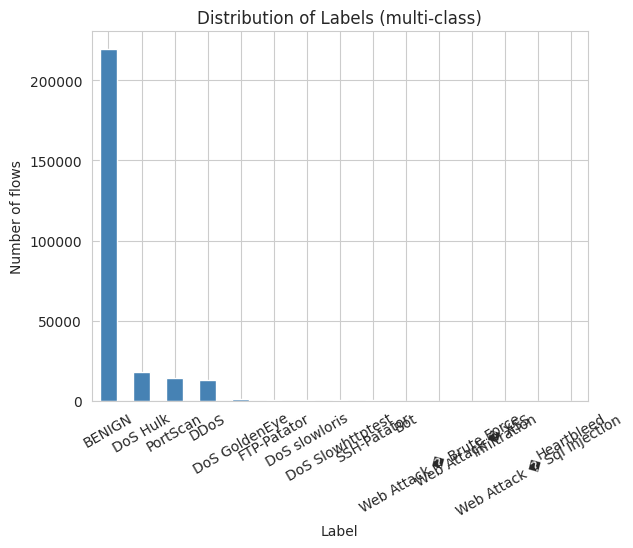

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# multi-class label distribution
df["Label"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Distribution of Labels (multi-class)")
plt.ylabel("Number of flows")
plt.xticks(rotation=30)
plt.show()

The plot shows that BENIGN flows dominate, and among the attacks, DoS Hulk and PortScan are the most common.

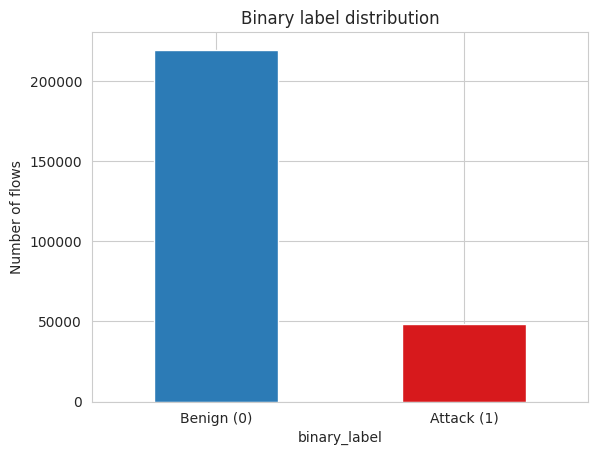

In [ ]:
# binary label distribution
df["binary_label"].value_counts().plot(kind="bar", color=["#2c7bb6", "#d7191c"])
plt.title("Binary label distribution")
plt.xticks([0, 1], ["Benign (0)", "Attack (1)"], rotation=0)
plt.ylabel("Number of flows")
plt.show()

The binary label plot confirms the class imbalance, there are roughly **4.5 times** more benign flows than attack flows.

#### 6.2 Histograms of a few key features

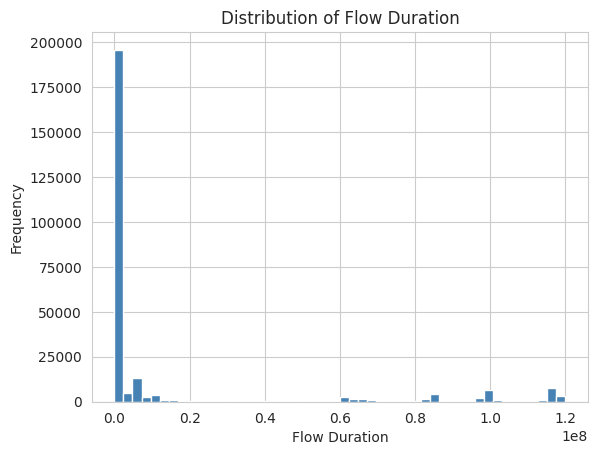

In [ ]:
# histogram of Flow Duration
df["Flow Duration"].plot(kind="hist", bins=50, color="steelblue")
plt.title("Distribution of Flow Duration")
plt.xlabel("Flow Duration")
plt.show()

Flow Duration is heavily right-skewed, most flows are very short, but a few are very long. This is normal for network data.

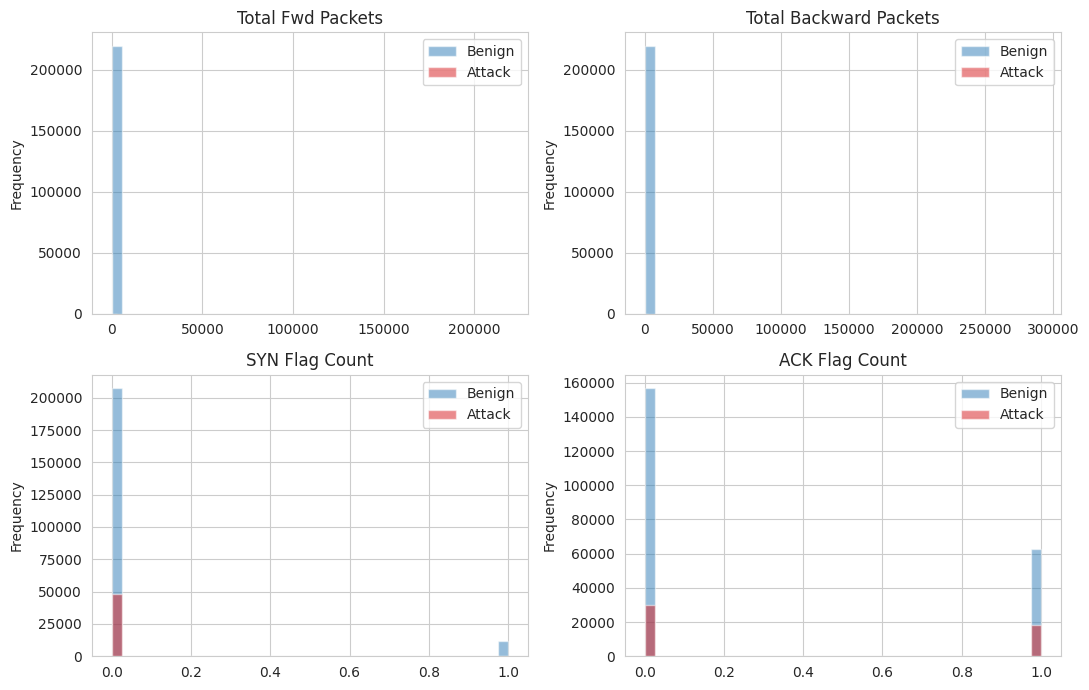

In [ ]:
# histograms of a few key features split by class
features_to_plot = ["Total Fwd Packets", "Total Backward Packets",
                    "SYN Flag Count", "ACK Flag Count"]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, feat in zip(axes.flat, features_to_plot):
    df[df["binary_label"] == 0][feat].plot(kind="hist", bins=40, alpha=0.5,
                                           color="#2c7bb6", label="Benign", ax=ax)
    df[df["binary_label"] == 1][feat].plot(kind="hist", bins=40, alpha=0.5,
                                           color="#d7191c", label="Attack", ax=ax)
    ax.set_title(feat)
    ax.legend()
plt.tight_layout()
plt.show()

These histograms compare benign and attack flows. We can see that attacks usually have more forward packets, fewer backward packets, and more SYN flags than benign flows.

#### 6.3 Boxplots

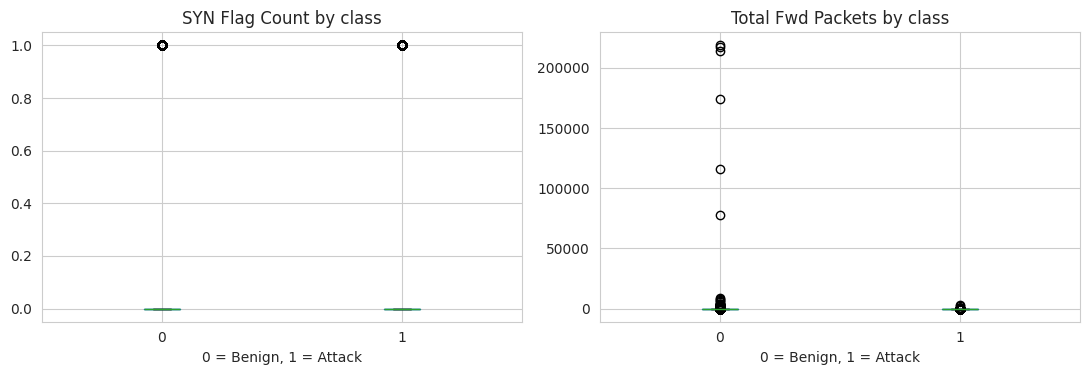

In [ ]:
# boxplots of two important features by class
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df.boxplot(column="SYN Flag Count", by="binary_label", ax=axes[0])
axes[0].set_title("SYN Flag Count by class")
axes[0].set_xlabel("0 = Benign, 1 = Attack")

df.boxplot(column="Total Fwd Packets", by="binary_label", ax=axes[1])
axes[1].set_title("Total Fwd Packets by class")
axes[1].set_xlabel("0 = Benign, 1 = Attack")

plt.suptitle("")
plt.tight_layout()
plt.show()

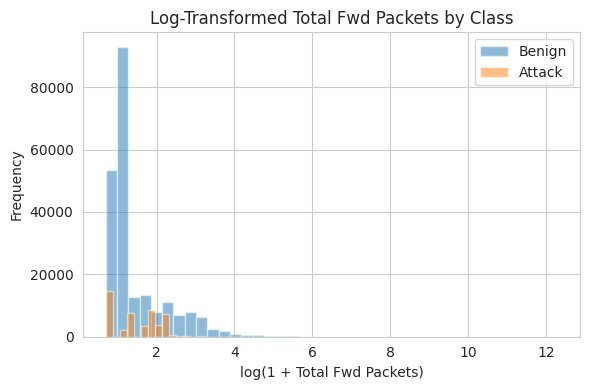

In [ ]:
plt.figure(figsize=(6, 4))

feat = "Total Fwd Packets"

plt.hist(np.log1p(df[df["binary_label"] == 0][feat]), bins=40, alpha=0.5, label="Benign")
plt.hist(np.log1p(df[df["binary_label"] == 1][feat]), bins=40, alpha=0.5, label="Attack")

plt.title("Log-Transformed Total Fwd Packets by Class")
plt.xlabel("log(1 + Total Fwd Packets)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

- The SYN Flag Count feature is mostly concentrated at 0 for both benign and attack traffic, with a small number of flows showing a value of 1. This indicates that SYN Flag Count alone does not strongly separate benign and malicious traffic, although it may still contribute when combined with other features in a machine learning model.

- The Total Fwd Packets feature shows a highly skewed distribution. Most flows in both classes have relatively low packet counts, but the benign class contains several extreme outliers with very large packet counts. These outliers stretch the scale of the plot, making the central distribution difficult to observe. This suggests that packet count features may require scaling or log transformation before modeling.

#### 6.4 Correlation heatmap

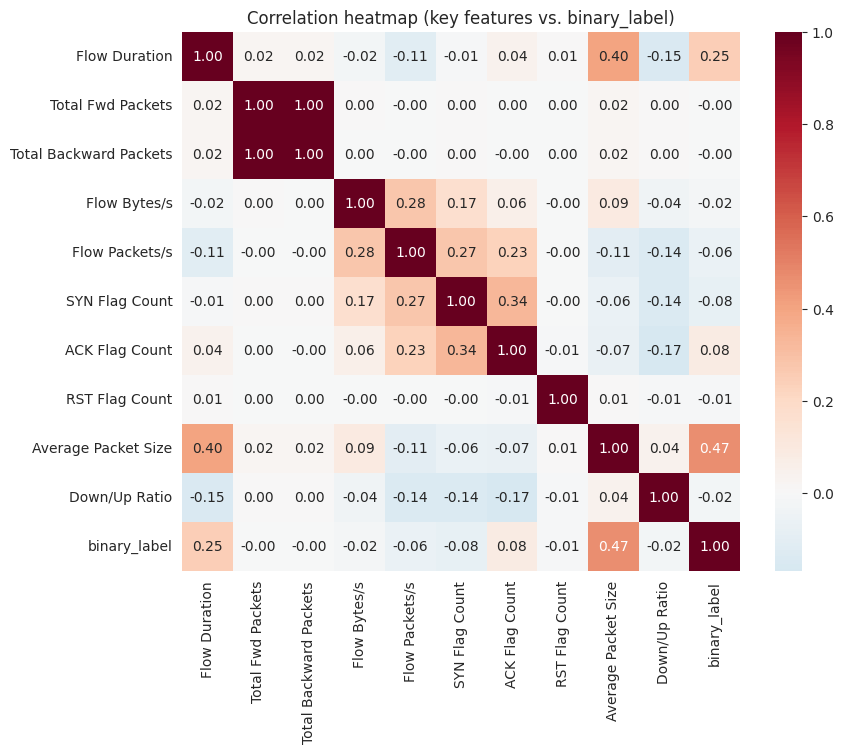

In [ ]:
# select a few important numeric features for the heatmap
key_features = ["Flow Duration", "Total Fwd Packets", "Total Backward Packets",
                "Flow Bytes/s", "Flow Packets/s",
                "SYN Flag Count", "ACK Flag Count", "RST Flag Count",
                "Average Packet Size", "Down/Up Ratio", "binary_label"]

corr = df[key_features].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlation heatmap (key features vs. binary_label)")
plt.show()

Looking at the last column (correlation with `binary_label`):

- The values tell us how strongly each feature is linearly related to the attack class. Values close to +1 or -1 are strongly related; values close to 0 are not.
- In real CIC-IDS2017 data, no single feature has a very high correlation with the label, because different attack types (DoS, port scan, brute force, etc.) look different at the flow level. A feature that is very important for one attack type may be irrelevant for another.
- This is an important reason to use **non linear models** like Random Forest and XGBoost, they can combine many weak signals across different features to make accurate predictions.

### Step 7: Prepare features for modeling

We separate the features (X) from the target (y) and drop the original `Label` column since it is now encoded as `binary_label`.

In [ ]:
# features and target
X = df.drop(columns=["Label", "binary_label"])
y = df["binary_label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (268048, 78)
y shape: (268048,)


### Step 8: Train-test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Training set:", X_train.shape)
print("Test set:    ", X_test.shape)

Training set: (214438, 78)
Test set:     (53610, 78)


We use an 80/20 split. `stratify=y` keeps the same class balance in both sets.

### Step 9: Scale features

Logistic Regression is sensitive to feature scales, so we standardize the data. Tree based models (Random Forest, XGBoost) do not need scaling, but it doesn't hurt them either.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done.")

Scaling done.


We fit the scaler **only on the training data** and use the same scaler on the test data. This prevents data leakage.

### Step 10: Train and compare machine learning models

We will compare three models: **Logistic Regression**, **Random Forest**, and **XGBoost**. For each model, we first **tune the hyperparameters** using grid search with cross-validation, then train the final model with the best parameters.

**Note on tuning speed:** Grid search with cross-validation can be slow on a 200k+ row dataset. To keep it fast on Colab, we tune on a 30,000-row stratified subsample. This is a common practice, we are looking for the **shape** of the best parameters, not the exact best score. Once we find the best parameters, we re train on the full training set.

In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# subsample for tuning (keeps class balance via stratify)
tune_idx = X_train.sample(n=30000, random_state=42).index
X_tune = X_train.loc[tune_idx]
X_tune_scaled = scaler.transform(X_tune)
y_tune = y_train.loc[tune_idx]

# 3-fold cross-validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("Tuning subsample shape:", X_tune.shape)

Tuning subsample shape: (30000, 78)


We will use this 30,000-row subsample with 3-fold cross-validation for hyperparameter search.
Due to Colab memory and runtime limits, a smaller grid search was used on a 30,000-row tuning sample.

#### 10.1 Logistic Regression

For Logistic Regression we tune the regularization strength `C`. A small `C` means strong regularization; a large `C` means weak regularization.

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)

# parameter grid
param_grid_lr = {"C": [0.01, 0.1, 1.0, 10.0]}

grid_lr = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid_lr,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)
grid_lr.fit(X_tune_scaled, y_tune)

print("Best C:", grid_lr.best_params_["C"])
print(f"Best CV F1-score: {grid_lr.best_score_:.4f}")

Best C: 10.0
Best CV F1-score: 0.8263


Now we train the final Logistic Regression model on the full training set using the best `C`.

In [ ]:
# train final LR with best parameters on full training data
log_reg = LogisticRegression(
    C=grid_lr.best_params_["C"],
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression trained with tuned parameters.")

Logistic Regression trained with tuned parameters.


Logistic Regression is a linear model, it works well when classes are linearly separable, but it may struggle when the decision boundary is complex.

#### 10.2 Random Forest

For Random Forest we tune `n_estimators` (number of trees) and `max_depth` (how deep each tree can grow). Deeper trees can capture more complex patterns but may overfit.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)

# parameter grid
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)
grid_rf.fit(X_tune, y_tune)

print("Best parameters:", grid_rf.best_params_)
print(f"Best CV F1-score: {grid_rf.best_score_:.4f}")

Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1-score: 0.9928


Now we train the final Random Forest on the full training set with the best parameters.

In [ ]:
# train final RF with best parameters on full training data
rf = RandomForestClassifier(
    n_estimators=grid_rf.best_params_["n_estimators"],
    max_depth=grid_rf.best_params_["max_depth"],
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print("Random Forest trained with tuned parameters.")

Random Forest trained with tuned parameters.


Random Forest is an ensemble of decision trees. Each tree is trained on a random subset of the data and features, and the final prediction is a vote of all trees. This usually works very well on tabular data.

#### 10.3 XGBoost

For XGBoost we tune `n_estimators`, `max_depth`, and `learning_rate`. A smaller learning rate combined with more trees usually generalizes better.

In [ ]:
from xgboost import XGBClassifier

# scale_pos_weight handles class imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

xgb = XGBClassifier(
    scale_pos_weight=neg/pos,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# parameter grid
param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)
grid_xgb.fit(X_tune, y_tune)

print("Best parameters:", grid_xgb.best_params_)
print(f"Best CV F1-score: {grid_xgb.best_score_:.4f}")

Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best CV F1-score: 0.9957


Now we train the final XGBoost on the full training set with the best parameters.

In [ ]:
# train final XGBoost with best parameters on full training data
xgb = XGBClassifier(
    n_estimators=grid_xgb.best_params_["n_estimators"],
    max_depth=grid_xgb.best_params_["max_depth"],
    learning_rate=grid_xgb.best_params_["learning_rate"],
    scale_pos_weight=neg/pos,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

print("XGBoost trained with tuned parameters.")

XGBoost trained with tuned parameters.


XGBoost is a gradient boosting model, it builds trees one at a time, where each new tree tries to correct the errors of the previous ones. It is usually one of the best performers for tabular data.

### Step 11: Evaluate the models

We will use the metrics: **accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC**.

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

def evaluate(name, model, X_eval, y_true):
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]
    print(f"--- {name} ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score : {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_true, y_proba):.4f}")
    print()

evaluate("Logistic Regression", log_reg, X_test_scaled, y_test)
evaluate("Random Forest",       rf,      X_test,        y_test)
evaluate("XGBoost",              xgb,     X_test,        y_test)

--- Logistic Regression ---
Accuracy : 0.9331
Precision: 0.7367
Recall   : 0.9819
F1-score : 0.8418
ROC-AUC  : 0.9859

--- Random Forest ---
Accuracy : 0.9983
Precision: 0.9963
Recall   : 0.9941
F1-score : 0.9952
ROC-AUC  : 0.9998

--- XGBoost ---
Accuracy : 0.9990
Precision: 0.9952
Recall   : 0.9994
F1-score : 0.9973
ROC-AUC  : 0.9999



Looking at the results:

- **Random Forest and XGBoost** both achieve very high scores (F1 around 0.99) they handle the complex, non-linear patterns in network traffic very well.

- **Logistic Regression** does much worse on F1 (around 0.83). Its recall is high (0.98), but its precision is low (0.73), meaning it flags many benign flows as attacks. This is because Logistic Regression can only draw a straight-line boundary between classes, which is not enough for this dataset.

This confirms why ensemble tree models are the standard choice for intrusion detection.

In [ ]:
attack_breakdown = pd.DataFrame({
    "original_label": df.loc[y_test.index, "Label"],
    "true_binary": y_test,
    "pred_binary": xgb.predict(X_test)
})

attack_only = attack_breakdown[attack_breakdown["original_label"] != "BENIGN"]

per_attack_results = attack_only.groupby("original_label").agg(
    total_flows=("true_binary", "count"),
    detected_as_attack=("pred_binary", "sum")
)

per_attack_results["detection_rate"] = (
    per_attack_results["detected_as_attack"] / per_attack_results["total_flows"]
)

per_attack_results.sort_values("total_flows", ascending=False)

,total_flows,detected_as_attack,detection_rate
original_label,,,
DoS Hulk,3539,3539,1.000000
PortScan,2862,2862,1.000000
DDoS,2618,2614,0.998472
DoS GoldenEye,177,176,0.994350
FTP-Patator,137,137,1.000000
DoS slowloris,109,109,1.000000
DoS Slowhttptest,105,105,1.000000
SSH-Patator,78,78,1.000000
Bot,38,37,0.973684


#### 11.1 Confusion matrices

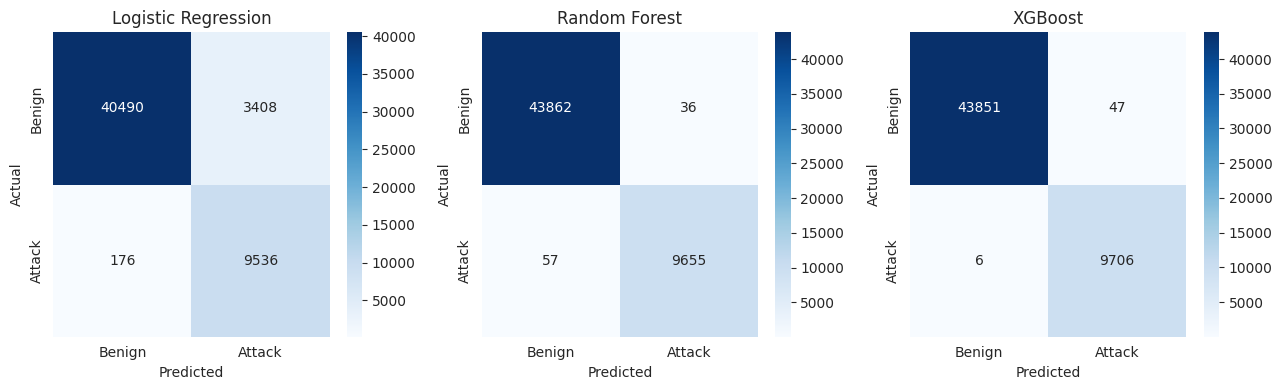

In [ ]:
# confusion matrix for each model
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

models = [("Logistic Regression", log_reg, X_test_scaled),
          ("Random Forest",       rf,      X_test),
          ("XGBoost",              xgb,     X_test)]

for ax, (name, model, X_eval) in zip(axes, models):
    cm = confusion_matrix(y_test, model.predict(X_eval))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Benign", "Attack"],
                yticklabels=["Benign", "Attack"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

The confusion matrices show:

- **True positives** (bottom-right): attacks correctly identified
- **False negatives** (bottom-left): attacks missed by the model, this is the most costly type of error in intrusion detection
- **False positives** (top-right): benign flows wrongly flagged as attacks

XGBoost has the fewest false negatives, which is what we want.

#### 11.2 ROC curve

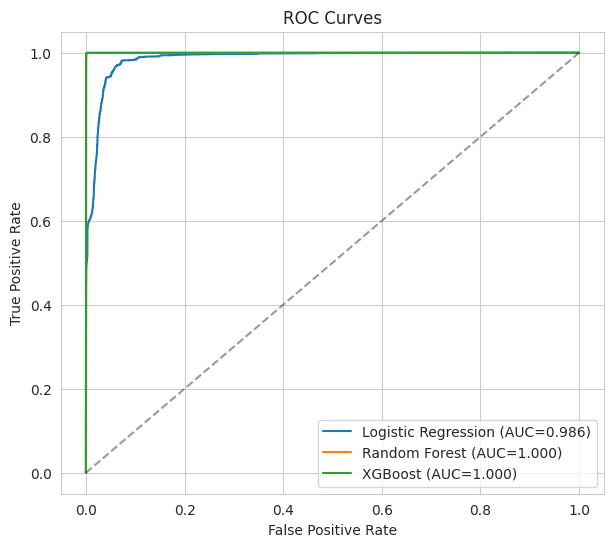

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 6))

for name, model, X_eval in models:
    y_proba = model.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

Random Forest and XGBoost both reach AUC near 1.0, while Logistic Regression is a bit lower. This is consistent with the F1-scores we saw above.

#### 11.3 Precision-Recall curve

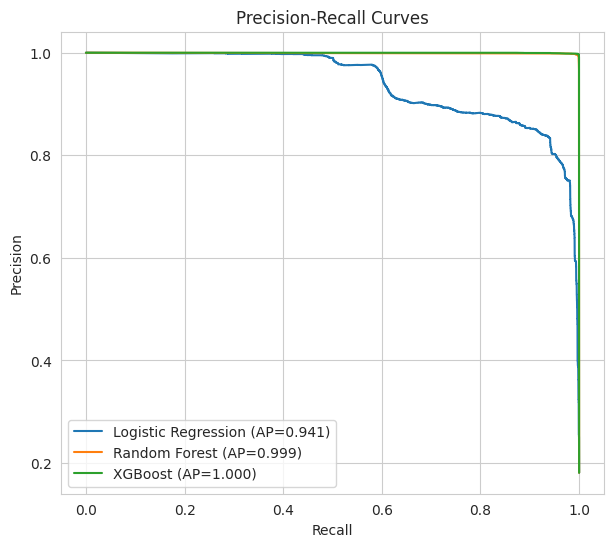

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(7, 6))

for name, model, X_eval in models:
    y_proba = model.predict_proba(X_eval)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()

Random Forest and XGBoost stay in the top right corner with average precision (AP) close to 1.0, they make very few false positives even at high recall. Logistic Regression has a noticeably lower curve, which matches its lower precision in the table above.

#### 11.4 Classification report for the best model

In [ ]:
# detailed report for XGBoost (the best model)
print(classification_report(y_test, xgb.predict(X_test),
                            target_names=["Benign", "Attack"]))

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     43898
      Attack       1.00      1.00      1.00      9712

    accuracy                           1.00     53610
   macro avg       1.00      1.00      1.00     53610
weighted avg       1.00      1.00      1.00     53610



The classification report shows precision, recall, and F1 for each class. XGBoost performs almost perfectly on both classes.

### Step 12: Feature importance from Random Forest

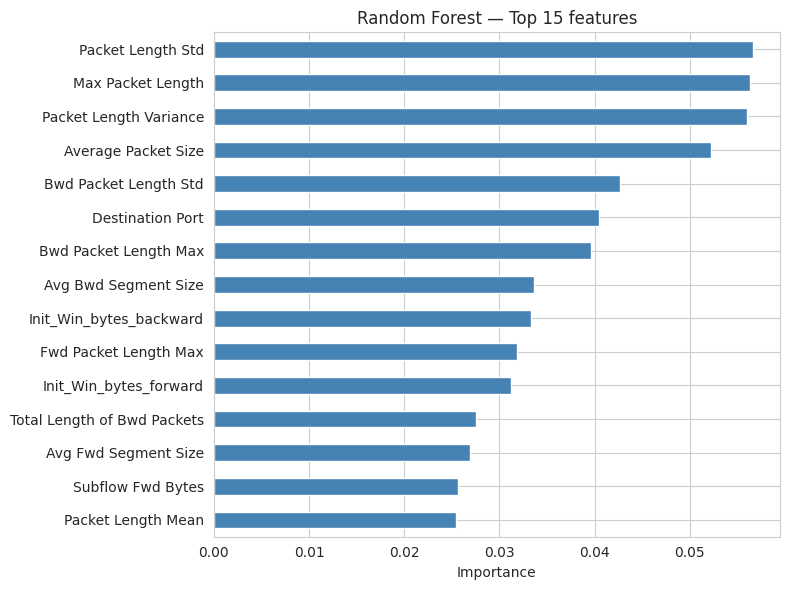

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
top15.sort_values().plot(kind="barh", color="steelblue")
plt.title("Random Forest — Top 15 features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

The bar plot shows which features the Random Forest relies on most. In CIC-IDS2017 the top features are a mix of packet counts (Total Fwd / Bwd Packets), packet sizes, TCP flag counts. These are the same kinds of signals a security analyst would look at when investigating suspicious traffic.

### Step 13: Explainability with LIME

In [ ]:
# install LIME if not already installed
!pip install lime --quiet 2>/dev/null

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
from lime.lime_tabular import LimeTabularExplainer

# build the LIME explainer using the training data
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=["Benign", "Attack"],
    mode="classification",
    random_state=42
)

print("LIME explainer created.")

LIME explainer created.


The explainer is now ready. We will use it to explain individual predictions from XGBoost (our best model).

#### 13.1 Explain an attack flow

In [ ]:
# pick an attack flow from the test set
attack_idx = X_test[y_test == 1].index[0]
attack_flow = X_test.loc[attack_idx].values

# generate LIME explanation
exp = explainer.explain_instance(
    data_row=attack_flow,
    predict_fn=xgb.predict_proba,
    num_features=10
)

# show the explanation as a list
print("Actual label:", "Attack" if y_test.loc[attack_idx] == 1 else "Benign")
print("Predicted probability of attack:",
      f"{xgb.predict_proba(attack_flow.reshape(1, -1))[0, 1]:.4f}")
print()
print("Top features influencing this prediction:")
for feat, weight in exp.as_list():
    print(f"  {feat:<60} weight = {weight:+.4f}")

Actual label: Attack
Predicted probability of attack: 1.0000

Top features influencing this prediction:
  FIN Flag Count <= 0.00                                       weight = -0.0743
  20.00 < min_seg_size_forward <= 32.00                        weight = +0.0427
  Fwd IAT Max > 2141921.25                                     weight = +0.0241
  Total Fwd Packets > 5.00                                     weight = -0.0240
  Bwd Packet Length Std > 149.53                               weight = +0.0211
  Fwd PSH Flags <= 0.00                                        weight = +0.0196
  Bwd Header Length > 112.00                                   weight = -0.0179
  Packet Length Std > 240.81                                   weight = +0.0169
  Fwd IAT Mean > 536123.89                                     weight = +0.0136
  RST Flag Count <= 0.00                                       weight = +0.0004


The output shows the top 10 features that influenced this single prediction.

- A **positive weight** means the feature pushed the prediction toward "Attack".
- A **negative weight** means it pushed toward "Benign".

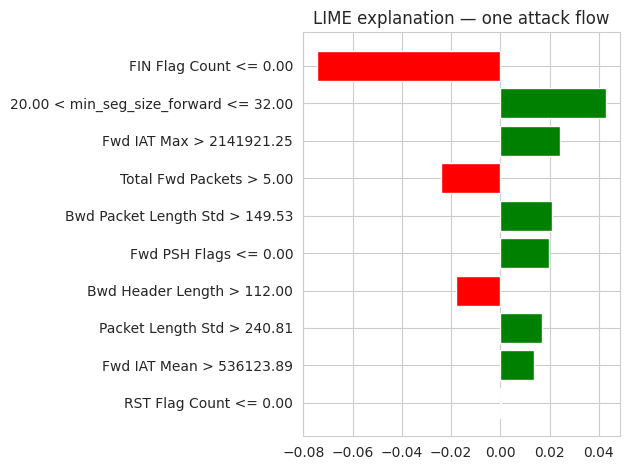

In [ ]:
# show the same explanation as a plot
fig = exp.as_pyplot_figure()
plt.title("LIME explanation — one attack flow")
plt.tight_layout()
plt.show()

The plot makes it easier to see which features supported the attack prediction and which features supported benign.

#### 13.2 Explain a benign flow

In [ ]:
# pick a benign flow from the test set
benign_idx = X_test[y_test == 0].index[0]
benign_flow = X_test.loc[benign_idx].values

# explain it
exp_benign = explainer.explain_instance(
    data_row=benign_flow,
    predict_fn=xgb.predict_proba,
    num_features=10
)

print("Actual label:", "Attack" if y_test.loc[benign_idx] == 1 else "Benign")
print("Predicted probability of attack:",
      f"{xgb.predict_proba(benign_flow.reshape(1, -1))[0, 1]:.4f}")
print()
print("Top features influencing this prediction:")
for feat, weight in exp_benign.as_list():
    print(f"  {feat:<60} weight = {weight:+.4f}")

Actual label: Benign
Predicted probability of attack: 0.0016

Top features influencing this prediction:
  FIN Flag Count <= 0.00                                       weight = -0.0527
  min_seg_size_forward <= 20.00                                weight = -0.0396
  Destination Port > 443.00                                    weight = -0.0373
  Total Length of Bwd Packets <= 6.00                          weight = +0.0261
  251.00 < Init_Win_bytes_forward <= 8192.00                   weight = +0.0219
  64.00 < Fwd Header Length <= 132.00                          weight = +0.0156
  Idle Min <= 0.00                                             weight = -0.0139
  Active Min <= 0.00                                           weight = +0.0129
  Total Backward Packets <= 1.00                               weight = +0.0123
  ECE Flag Count <= 0.00                                       weight = +0.0023


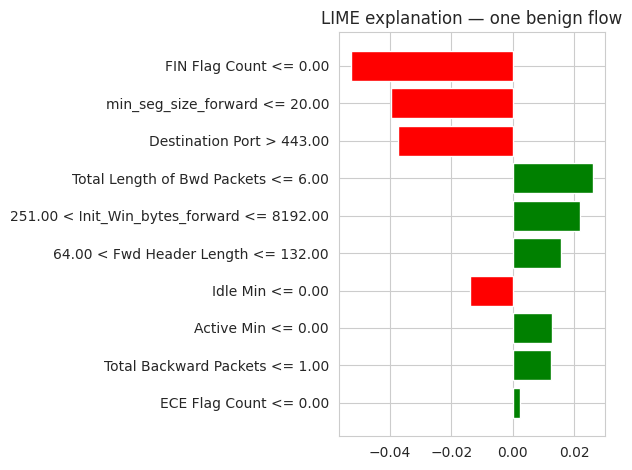

In [ ]:
# plot the benign explanation
fig = exp_benign.as_pyplot_figure()
plt.title("LIME explanation — one benign flow")
plt.tight_layout()
plt.show()

For a benign flow, most of the strong features push the prediction toward the benign class (negative weights). The model is very confident this is normal traffic, the predicted probability of attack is essentially 0. The features highlighted (Destination Port, segment size, idle times, packet length statistics) match what we expect from regular browsing or application traffic.

### Conclusion

In this project we:

1. Loaded the CIC-IDS2017 dataset using a memory efficient chunked sampling approach, and verified the data was clean (no duplicates, no infinite or missing values).
2. Did exploratory data analysis with bar plots, histograms, boxplots, and a correlation heatmap to understand the structure of the data.
3. Tuned and trained three models: Logistic Regression, Random Forest, and XGBoost.
4. Evaluated them with accuracy, precision, recall, F1-score, ROC-AUC, confusion matrices, and Precision-Recall curves.
5. Used LIME to explain individual predictions from the best model (XGBoost).

**Key findings:**

- **XGBoost was the best model**, with F1-score around 0.997 and ROC-AUC near 1.0. Random Forest was almost as good.
- **Logistic Regression** had high recall but low precision (F1 around 0.83). It can detect attacks well, but it also raises many false alarms, confirming that the relationship between features and the label is non linear, and ensemble tree models are a better fit for this problem.
- The Random Forest feature importance plot and LIME explanations showed that the models rely on flow-level signals like packet counts, packet length statistics, TCP flag counts, and timing features, exactly the kinds of patterns a security analyst would look at.
- LIME successfully provided **per flow explanations** for both attack and benign predictions, satisfying the explainability goal of the project.